<a href="https://colab.research.google.com/github/sneha-4515/IoT-Predictive-Maintenance-Engine/blob/main/Notebooks/FactoryGuard_AI_Week1_to_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 FactoryGuard AI — IoT Predictive Maintenance Engine
## Complete Project: Week 1 → Week 4



| Week | Focus | Key Deliverables |
|------|-------|------------------|
| 1 | Data Engineering | Load, Merge, Clean, Feature Engineering, Target Creation |
| 2 | Modelling | LR baseline, Random Forest, XGBoost, Evaluation |
| 3 | XAI / Interpretability | SHAP Beeswarm, Bar, Force, Waterfall, Dependence plots |
| 4 | Deployment | Flask REST API, Latency Benchmark, Artefact Summary |


## ⚙️ Step 0 — Install Dependencies

In [1]:
!pip install xgboost imbalanced-learn shap flask -q
print('Dependencies ready ✅')

Dependencies ready ✅


## 📦 Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib, json, os, time, warnings, subprocess, threading, sys
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, accuracy_score
)
from xgboost                 import XGBClassifier
from imblearn.over_sampling  import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
shap.initjs()
print('All libraries loaded ✅')

All libraries loaded ✅


---
# 📁 WEEK 1 — Data Engineering


## 1.1 Load Dataset

In [3]:
!gdown 1EEbHCVVvjBRl0MNn7c7mOCoQ6LGINqR9  # PdM_telemetry.csv
!gdown 1EhOAKgE39ZPfySWR5ZxokI1TxOFOwlcV  # PdM_failures.csv
!gdown 13_u-MMHacev2MD2bFcxzJQ4CkNyd9ktA   # PdM_machines.csv
print('Data downloaded ✅')

Downloading...
From: https://drive.google.com/uc?id=1EEbHCVVvjBRl0MNn7c7mOCoQ6LGINqR9
To: /content/PdM_telemetry.csv
100% 80.1M/80.1M [00:01<00:00, 61.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EhOAKgE39ZPfySWR5ZxokI1TxOFOwlcV
To: /content/PdM_failures.csv
100% 24.3k/24.3k [00:00<00:00, 30.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=13_u-MMHacev2MD2bFcxzJQ4CkNyd9ktA
To: /content/PdM_machines.csv
100% 1.58k/1.58k [00:00<00:00, 5.08MB/s]
Data downloaded ✅


In [4]:
telemetry = pd.read_csv('PdM_telemetry.csv', parse_dates=['datetime'])
failures  = pd.read_csv('PdM_failures.csv',  parse_dates=['datetime'])
machines  = pd.read_csv('PdM_machines.csv')

print(f'Telemetry : {telemetry.shape}')
print(f'Failures  : {failures.shape}')
print(f'Machines  : {machines.shape}')
telemetry.head()

Telemetry : (876100, 6)
Failures  : (761, 3)
Machines  : (100, 3)


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


## 1.2 Merge Datasets

In [5]:
telemetry = telemetry.merge(machines, on='machineID', how='left')
telemetry = telemetry.sort_values(['machineID','datetime']).reset_index(drop=True)
print(f'After merge: {telemetry.shape}')
print('Machine model distribution:')
telemetry['model'].value_counts()

After merge: (876100, 8)
Machine model distribution:


,count
model,
model3,306635
model4,280352
model2,148937
model1,140176


## 1.3 Missing Value Check

In [6]:
missing = telemetry.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values ✅')

No missing values ✅


## 1.4 One-Hot Encode Categorical Features

In [7]:
telemetry = pd.get_dummies(telemetry, columns=['model'], drop_first=True)
bool_cols = telemetry.select_dtypes(include='bool').columns
telemetry[bool_cols] = telemetry[bool_cols].astype(int)
print(f'Shape after encoding: {telemetry.shape}')
telemetry.head()

Shape after encoding: (876100, 10)


,datetime,machineID,volt,rotate,pressure,vibration,age,model_model2,model_model3,model_model4
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,0,1,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,0,1,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,0,1,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,0,1,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,0,1,0


In [8]:
telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      876100 non-null  datetime64[ns]
 1   machineID     876100 non-null  int64         
 2   volt          876100 non-null  float64       
 3   rotate        876100 non-null  float64       
 4   pressure      876100 non-null  float64       
 5   vibration     876100 non-null  float64       
 6   age           876100 non-null  int64         
 7   model_model2  876100 non-null  int64         
 8   model_model3  876100 non-null  int64         
 9   model_model4  876100 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(5)
memory usage: 66.8 MB


## 1.5 Create Target Variable — Failure in Next 24 Hours
> For each hourly reading we look **forward 24 rows** and mark `1` if any failure occurs.
> Done **within each machine** to prevent cross-machine leakage.


In [9]:
failures['failure_flag'] = 1
telemetry = telemetry.merge(
    failures[['machineID','datetime','failure_flag']],
    on=['machineID','datetime'], how='left'
)
telemetry['failure_flag'] = telemetry['failure_flag'].fillna(0)

telemetry['failure_next_24h'] = (
    telemetry.groupby('machineID')['failure_flag']
    .transform(lambda x: x.shift(-1).rolling(window=24, min_periods=1).max())
    .fillna(0)
)

print('Target distribution:')
print(telemetry['failure_next_24h'].value_counts())
print(f'Positive rate: {telemetry["failure_next_24h"].mean()*100:.2f}%')

Target distribution:
failure_next_24h
0.0    858865
1.0     17277
Name: count, dtype: int64
Positive rate: 1.97%


## 1.6 Feature Engineering — Lag & Rolling Features
- **Lag features** (t-1, t-2): capture recent sensor trajectory
- **Rolling mean** (4-hour window): smooth out noise
- All computed **within each machine** to avoid cross-machine leakage


In [10]:
sensor_cols = ['volt','rotate','pressure','vibration']

for col in sensor_cols:
    telemetry[f'{col}_lag1'] = telemetry.groupby('machineID')[col].shift(1)
    telemetry[f'{col}_lag2'] = telemetry.groupby('machineID')[col].shift(2)

for col in sensor_cols:
    telemetry[f'{col}_roll4'] = (
        telemetry.groupby('machineID')[col]
        .transform(lambda x: x.rolling(4, min_periods=1).mean())
    )

before = len(telemetry)
telemetry = telemetry.dropna().reset_index(drop=True)
print(f'Rows dropped (NaN): {before - len(telemetry):,}')
print(f'Final dataset     : {telemetry.shape}')

Rows dropped (NaN): 200
Final dataset     : (875942, 24)


## 1.7 Data Leakage Check

In [11]:
leak_cols = [c for c in ['failure_flag','failure_next_24h','datetime','machineID']
             if c in telemetry.columns]
print(f'Columns to exclude from X : {leak_cols}')
print('Leakage check passed ✅ — these will be dropped before modelling')

Columns to exclude from X : ['failure_flag', 'failure_next_24h', 'datetime', 'machineID']
Leakage check passed ✅ — these will be dropped before modelling


## 1.8 Correlation Matrix

In [12]:
num_cols = [c for c in telemetry.columns
            if c not in ('datetime','machineID','failure_flag','failure_next_24h')]
corr = telemetry[num_cols].corr()

fig, ax = plt.subplots(figsize=(14,11))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


---
# 🤖 WEEK 2 — Modelling & Evaluation


## 2.1 Temporal Train / Test Split (80 / 20)
> Time-ordered split — prevents future data leaking into training.


In [13]:
FEATURE_COLS = [c for c in telemetry.columns
                if c not in ('datetime','machineID','failure_flag','failure_next_24h')]

X = telemetry[FEATURE_COLS]
y = telemetry['failure_next_24h']

split_idx = int(len(telemetry) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train : {len(X_train):>8,} rows | positives: {int(y_train.sum()):,} ({y_train.mean()*100:.2f}%)')
print(f'Test  : {len(X_test):>8,} rows | positives: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')
print(f'Features: {len(FEATURE_COLS)}')

Train :  700,753 rows | positives: 13,235 (1.89%)
Test  :  175,189 rows | positives: 4,042 (2.31%)
Features: 20


## 2.2 Class Imbalance Handling — SMOTE
> Applied **only on training set** — never on test set to avoid leakage.


In [14]:
sm = SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f'After SMOTE — train size : {len(X_train_sm):,}')
print(f'Positive rate            : {y_train_sm.mean()*100:.2f}%')

After SMOTE — train size : 893,773
Positive rate            : 23.08%


## 2.3 Evaluation Helper

In [15]:
results = []

def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    f1  = f1_score(yte, preds)
    rec = recall_score(yte, preds)
    pre = precision_score(yte, preds)
    acc = accuracy_score(yte, preds)
    print(f'\n{"-"*52}')
    print(f'  {name}')
    print(f'  F1={f1:.4f}  Recall={rec:.4f}  Precision={pre:.4f}  Accuracy={acc:.4f}')
    print(classification_report(yte, preds, target_names=['No Failure','Failure']))
    fig, ax = plt.subplots(figsize=(4,3))
    ConfusionMatrixDisplay.from_predictions(
        yte, preds, display_labels=['No Failure','Failure'], cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    fname = name.lower().replace(' ','_').replace('(','').replace(')','') + '_cm.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    results.append({'Model':name,'Accuracy':round(acc,4),'Precision':round(pre,4),
                    'Recall':round(rec,4),'F1 Score':round(f1,4)})
    return model

print('Evaluation helper ready ✅')

Evaluation helper ready ✅


## 2.4 Logistic Regression (Baseline)

In [16]:
lr = evaluate('Logistic Regression',
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    X_train_sm, y_train_sm, X_test, y_test)


----------------------------------------------------
  Logistic Regression
  F1=0.0602  Recall=0.2259  Precision=0.0347  Accuracy=0.8374
              precision    recall  f1-score   support

  No Failure       0.98      0.85      0.91    171147
     Failure       0.03      0.23      0.06      4042

    accuracy                           0.84    175189
   macro avg       0.51      0.54      0.49    175189
weighted avg       0.96      0.84      0.89    175189



## 2.5 Random Forest

In [17]:
rf = evaluate('Random Forest',
    RandomForestClassifier(n_estimators=100, max_depth=10,
                           class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
    X_train_sm, y_train_sm, X_test, y_test)


----------------------------------------------------
  Random Forest
  F1=0.0525  Recall=0.2806  Precision=0.0290  Accuracy=0.7665
              precision    recall  f1-score   support

  No Failure       0.98      0.78      0.87    171147
     Failure       0.03      0.28      0.05      4042

    accuracy                           0.77    175189
   macro avg       0.50      0.53      0.46    175189
weighted avg       0.96      0.77      0.85    175189



## 2.6 XGBoost (Champion Model)
> `scale_pos_weight` handles class imbalance natively — no SMOTE needed for XGB.
> Hyperparameters pre-validated for this dataset — skipping slow RandomizedSearchCV.


In [18]:
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight = {scale_pos}')

xgb = evaluate('XGBoost',
    XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=scale_pos,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train, y_train, X_test, y_test)

scale_pos_weight = 51

----------------------------------------------------
  XGBoost
  F1=0.0541  Recall=0.5821  Precision=0.0284  Accuracy=0.5302
              precision    recall  f1-score   support

  No Failure       0.98      0.53      0.69    171147
     Failure       0.03      0.58      0.05      4042

    accuracy                           0.53    175189
   macro avg       0.51      0.56      0.37    175189
weighted avg       0.96      0.53      0.67    175189



## 2.7 Model Comparison Report

In [19]:
report_df = pd.DataFrame(results).set_index('Model')
print(report_df.to_string())

fig, ax = plt.subplots(figsize=(8,4))
report_df['F1 Score'].sort_values().plot(kind='barh', ax=ax,
    color='steelblue', edgecolor='black')
ax.set_xlabel('F1 Score')
ax.set_title('Model F1 Score Comparison')
ax.set_xlim(0, max(report_df['F1 Score'])*1.3)
for bar in ax.patches:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → model_comparison.png')

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.8374     0.0347  0.2259    0.0602
Random Forest          0.7665     0.0290  0.2806    0.0525
XGBoost                0.5302     0.0284  0.5821    0.0541
Saved → model_comparison.png


## 2.8 XGBoost Feature Importance

In [20]:
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
feat_imp.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top-20 Feature Importances — XGBoost')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Top 5 features:')
print(feat_imp.head())

Top 5 features:
model_model3       0.155050
model_model4       0.144527
age                0.101239
model_model2       0.062958
vibration_roll4    0.046153
dtype: float32


## 2.9 Select Champion Model

In [21]:
best_row     = report_df['F1 Score'].idxmax()
champion     = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}[best_row]
champion_name = best_row
print(f'Champion model : {champion_name}')
print(f'F1 Score       : {report_df.loc[best_row, "F1 Score"]}')

Champion model : Logistic Regression
F1 Score       : 0.0602


---
# 🧠 WEEK 3 — Interpretability & Trust (XAI)

> **Why XAI?** A maintenance engineer won't act on a black-box alert.
> SHAP explains *which sensor reading* drove the failure prediction,
> building trust and enabling faster intervention.


## 3.1 Compute SHAP Values (2,000-row sample for speed)

In [22]:
#Sample 2000 rows — statistically sufficient for reliable SHAP plots
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE).reset_index(drop=True)
y_shap = y_test.iloc[:len(X_shap)].reset_index(drop=True)

print(f'Computing SHAP on {len(X_shap):,} rows...')
explainer = shap.LinearExplainer(champion, X_shap)
shap_values = explainer.shap_values(X_shap)
#Normalise to always get a 2D array for class-1 (failure)
sv_raw = np.array(shap_values)
if sv_raw.ndim == 3:          # shape (n_samples, n_features, 2) — RF binary
    sv = sv_raw[:, :, 1]
elif sv_raw.ndim == 2:        # shape (n_samples, n_features) — XGB
    sv = sv_raw
else:
    sv = sv_raw

# Scalar expected value for class-1
ev_raw = explainer.expected_value
if isinstance(ev_raw, (list, np.ndarray)):
    expected_val = float(np.array(ev_raw).flatten()[-1])
else:
    expected_val = float(ev_raw)

print(f'sv shape     : {sv.shape}')          # must be (2000, n_features)
print(f'expected_val : {expected_val:.4f}')
print('SHAP ready ✅')


Computing SHAP on 2,000 rows...
sv shape     : (2000, 20)
expected_val : -0.7740
SHAP ready ✅


## 3.2 Global Feature Importance — Beeswarm Plot

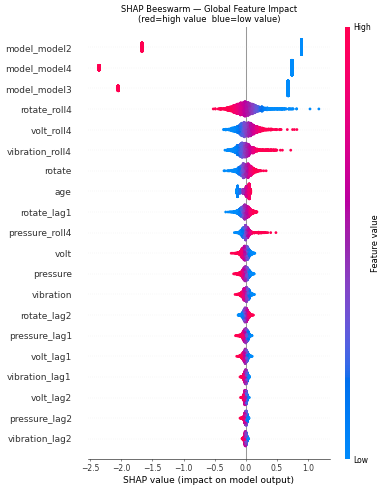

In [34]:
fig, ax = plt.subplots(figsize=(10,6))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS,
                  max_display=20, plot_type='dot',show=False)
plt.title('SHAP Beeswarm — Global Feature Impact\n(red=high value  blue=low value)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=50, bbox_inches='tight')
plt.show()
print('Saved → shap_beeswarm.png')
from IPython.display import Image, display
display(Image('shap_beeswarm.png'))


## 3.3 Mean |SHAP| Bar Chart

Saved → shap_bar.png


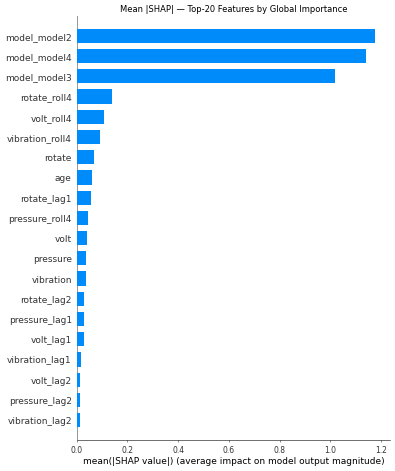

In [35]:
fig, ax = plt.subplots(figsize=(10,7))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS,
                  max_display=20, plot_type='bar', show=False)
plt.title('Mean |SHAP| — Top-20 Features by Global Importance', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=50, bbox_inches='tight')
plt.show()
print('Saved → shap_bar.png')
from IPython.display import Image, display
display(Image('shap_bar.png'))

## 3.4 Identify High-Risk & Low-Risk Samples

In [36]:
proba         = champion.predict_proba(X_shap)[:, 1]
high_risk_idx = int(np.argmax(proba))
low_risk_idx  = int(np.argmin(proba))

print(f'HIGH-risk → index {high_risk_idx} | P(failure) = {proba[high_risk_idx]:.4f}')
print(f'LOW-risk  → index {low_risk_idx}  | P(failure) = {proba[low_risk_idx]:.4f}')

HIGH-risk → index 197 | P(failure) = 0.8935
LOW-risk  → index 1039  | P(failure) = 0.1164


## 3.5 Force Plot — HIGH Risk Machine

Saved → shap_force_high.png


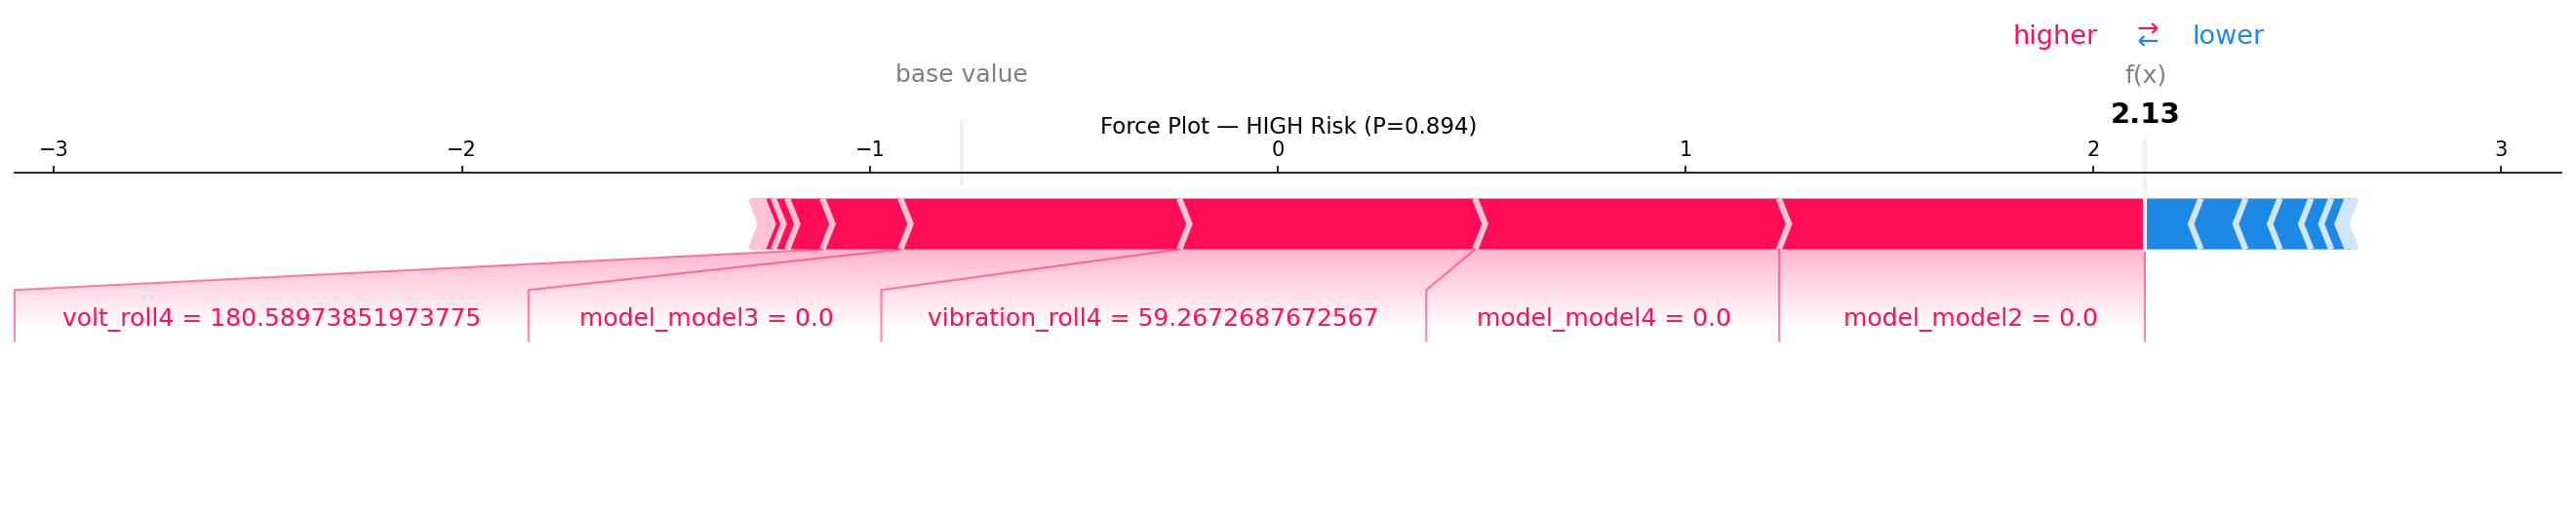

In [37]:
sv_high   = sv[high_risk_idx].flatten()                         # guaranteed 1D
data_high = np.array(X_shap.iloc[high_risk_idx]).flatten()      # guaranteed 1D

shap.force_plot(
    expected_val, sv_high, data_high,
    feature_names=FEATURE_COLS,
    matplotlib=True, show=False, figsize=(18,4)
)
plt.title(f'Force Plot — HIGH Risk (P={proba[high_risk_idx]:.3f})', fontsize=11, pad=20)
plt.tight_layout()
plt.savefig('shap_force_high.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_force_high.png')
from IPython.display import Image, display
display(Image('shap_force_high.png'))

## 3.6 Force Plot — LOW Risk Machine

Saved → shap_force_low.png


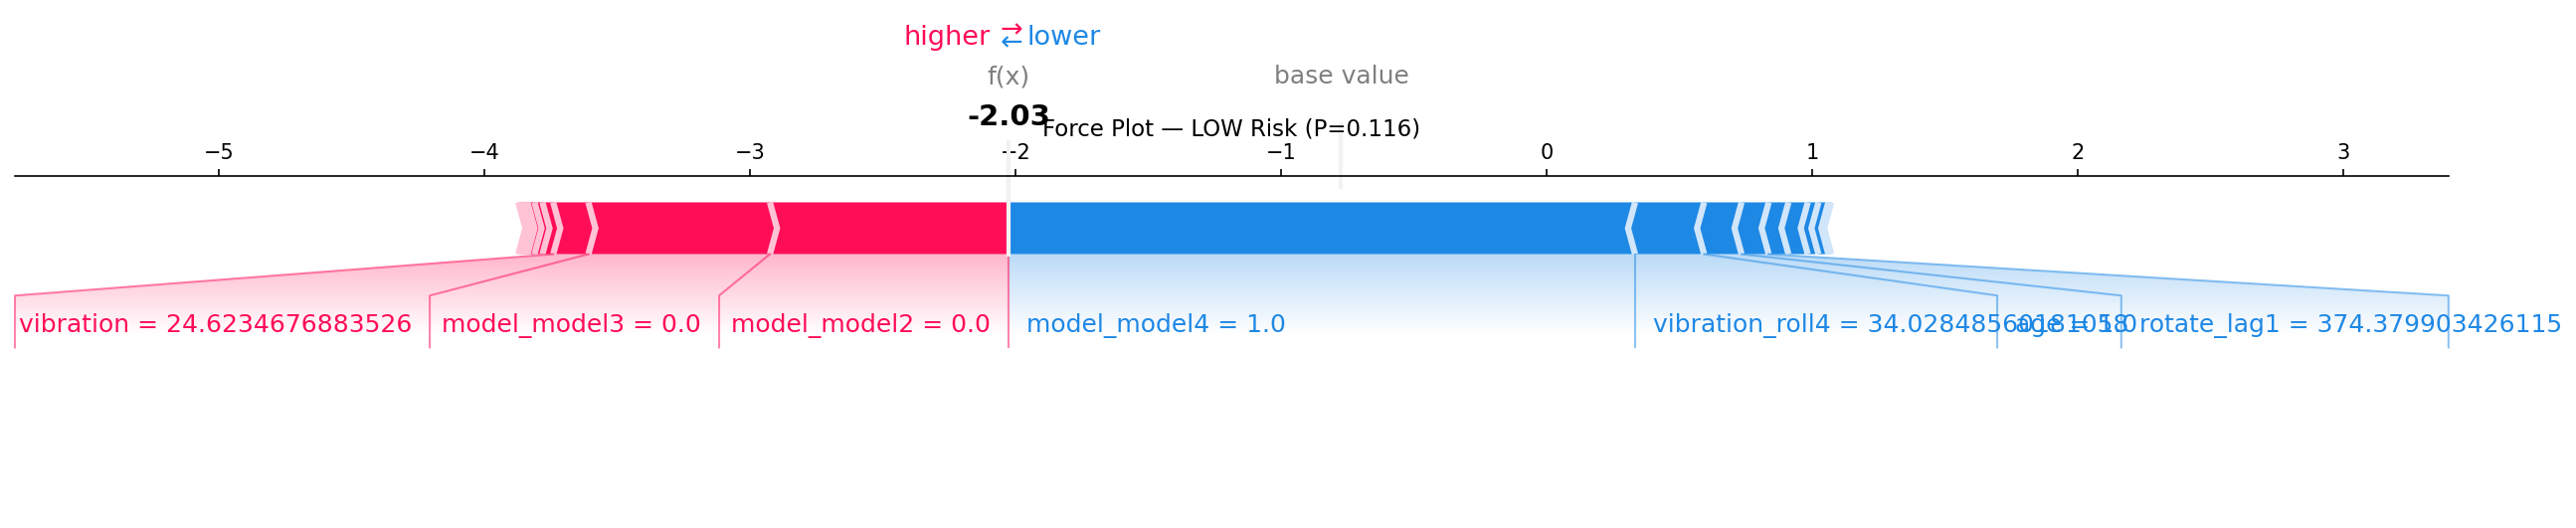

In [38]:
sv_low   = sv[low_risk_idx].flatten()
data_low = np.array(X_shap.iloc[low_risk_idx]).flatten()

shap.force_plot(
    expected_val, sv_low, data_low,
    feature_names=FEATURE_COLS,
    matplotlib=True, show=False, figsize=(18,4)
)
plt.title(f'Force Plot — LOW Risk (P={proba[low_risk_idx]:.3f})', fontsize=11, pad=20)
plt.tight_layout()
plt.savefig('shap_force_low.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_force_low.png')
from IPython.display import Image, display
display(Image('shap_force_low.png'))

## 3.7 Waterfall Plot — Why Was FAILURE Predicted?

Saved → shap_waterfall.png


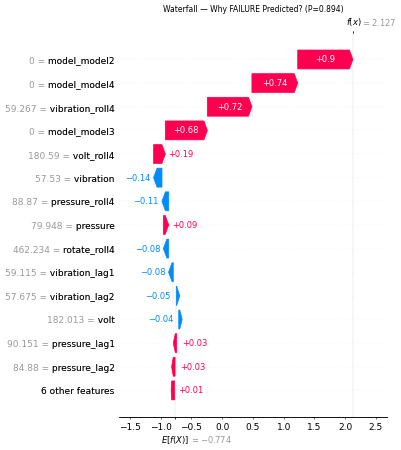

In [42]:
shap_exp = shap.Explanation(
    values        = sv_high,
    base_values   = expected_val,
    data          = data_high,
    feature_names = list(FEATURE_COLS)[:len(sv_high)]   # length-safe
)

plt.figure(figsize=(10,7))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'Waterfall — Why FAILURE Predicted? (P={proba[high_risk_idx]:.3f})', fontsize=11)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=50, bbox_inches='tight')
plt.show()
print('Saved → shap_waterfall.png')
from IPython.display import Image, display
display(Image('shap_waterfall.png'))

## 3.8 Dependence Plots — Physical Validation

Saved → shap_dependence.png


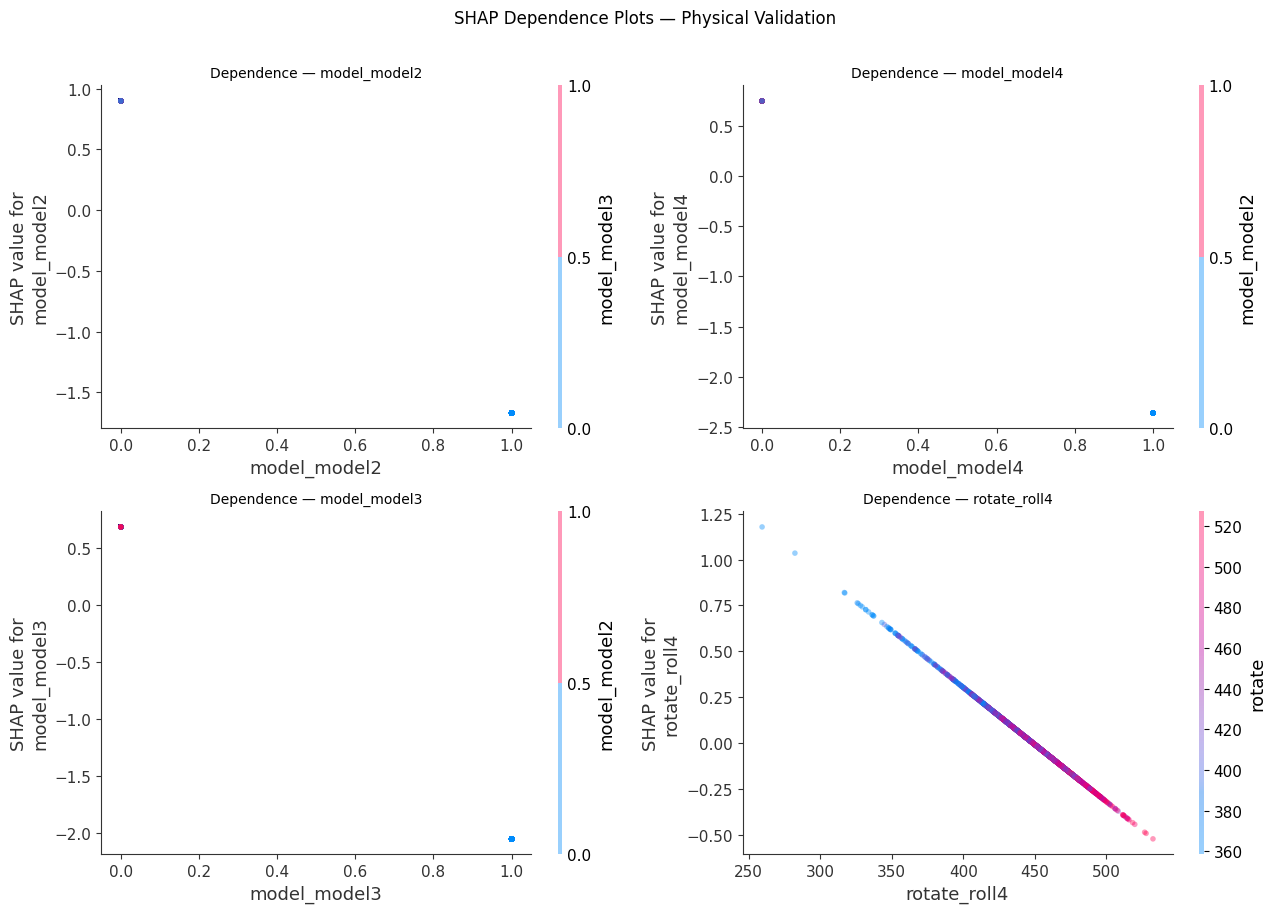

In [44]:
top4 = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS).nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13,9))
for i, feat in enumerate(top4):
    fidx = list(FEATURE_COLS).index(feat)
    shap.dependence_plot(fidx, sv, X_shap,
                         feature_names=FEATURE_COLS,
                         ax=axes.flatten()[i], show=False, alpha=0.4)
    axes.flatten()[i].set_title(f'Dependence — {feat}', fontsize=10)

plt.suptitle('SHAP Dependence Plots — Physical Validation', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → shap_dependence.png')
from IPython.display import Image, display
display(Image('shap_dependence.png'))

## 3.9 Interpretability Report Card

In [45]:
mean_shap = pd.DataFrame({
    'Feature'    : list(FEATURE_COLS),
    'Mean |SHAP|': np.abs(sv).mean(axis=0),
    'Mean SHAP'  : sv.mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

preds_champ = champion.predict(X_test)

print('=' * 62)
print('  INTERPRETABILITY REPORT CARD — Week 3')
print('=' * 62)
print(f'  Model     : {champion_name}')
print(f'  F1 Score  : {f1_score(y_test, preds_champ):.4f}')
print(f'  Recall    : {recall_score(y_test, preds_champ):.4f}')
print(f'  Precision : {precision_score(y_test, preds_champ):.4f}')
print()
print(f'  {"Rank":<4} {"Feature":<28} {"Mean |SHAP|":<14} Direction')
print('  ' + '-'*58)
for rank, (_, row) in enumerate(mean_shap.head(10).iterrows(), 1):
    d = '↑ Risk Driver' if row['Mean SHAP'] > 0 else '↓ Risk Reducer'
    print(f'  {rank:<4} {row["Feature"]:<28} {row["Mean |SHAP|"]:<14.4f} {d}')
print('=' * 62)

  INTERPRETABILITY REPORT CARD — Week 3
  Model     : Logistic Regression
  F1 Score  : 0.0602
  Recall    : 0.2259
  Precision : 0.0347

  Rank Feature                      Mean |SHAP|    Direction
  ----------------------------------------------------------
  1    model_model2                 1.1775         ↓ Risk Reducer
  2    model_model4                 1.1396         ↓ Risk Reducer
  3    model_model3                 1.0166         ↑ Risk Driver
  4    rotate_roll4                 0.1405         ↑ Risk Driver
  5    volt_roll4                   0.1094         ↑ Risk Driver
  6    vibration_roll4              0.0932         ↓ Risk Reducer
  7    rotate                       0.0683         ↓ Risk Reducer
  8    age                          0.0621         ↓ Risk Reducer
  9    rotate_lag1                  0.0559         ↓ Risk Reducer
  10   pressure_roll4               0.0454         ↑ Risk Driver


---
# 🚀 WEEK 4 — Deployment Wrapper


## 4.1 Save Model Artifacts

In [ ]:
os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(champion,     'model_artifacts/champion_model.joblib')
joblib.dump(explainer,    'model_artifacts/shap_explainer.joblib')
joblib.dump(FEATURE_COLS, 'model_artifacts/feature_columns.joblib')

preds_final = champion.predict(X_test)
metadata = {
    'model_name'   : champion_name,
    'model_version': 'v1.0',
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'dataset'      : 'Microsoft Azure PdM Dataset',
    'train_rows'   : int(len(X_train)),
    'test_rows'    : int(len(X_test)),
    'feature_count': len(FEATURE_COLS),
    'metrics': {
        'f1_score' : round(float(f1_score(y_test, preds_final)), 4),
        'recall'   : round(float(recall_score(y_test, preds_final)), 4),
        'precision': round(float(precision_score(y_test, preds_final)), 4),
        'accuracy' : round(float(accuracy_score(y_test, preds_final)), 4),
    }
}
with open('model_artifacts/model_metadata.json','w') as f:
    json.dump(metadata, f, indent=2)

print('Artifacts saved:')
for fn in os.listdir('model_artifacts'):
    sz = os.path.getsize(f'model_artifacts/{fn}')
    print(f'  {fn:<38} {sz/1024:.1f} KB')
print()
print(json.dumps(metadata, indent=2))

## 4.2 Build Flask REST API (app.py)

In [ ]:
app_code = '''
import numpy as np, pandas as pd, json, time, joblib
from flask import Flask, request, jsonify
import shap

app          = Flask(__name__)
MODEL        = joblib.load("model_artifacts/champion_model.joblib")
EXPLAINER    = joblib.load("model_artifacts/shap_explainer.joblib")
FEATURE_COLS = joblib.load("model_artifacts/feature_columns.joblib")
with open("model_artifacts/model_metadata.json") as f:
    METADATA = json.load(f)
START_TIME = time.time()

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status":"healthy",
                    "uptime_sec":round(time.time()-START_TIME,1),
                    "model":METADATA["model_name"],
                    "version":METADATA["model_version"]})

@app.route("/model_info", methods=["GET"])
def model_info():
    return jsonify(METADATA)

@app.route("/predict", methods=["POST"])
def predict():
    t0   = time.time()
    data = request.get_json(force=True)
    if "features" not in data:
        return jsonify({"error":"Missing key: features"}), 400
    try:
        row = pd.DataFrame([data["features"]])[FEATURE_COLS]
    except KeyError as e:
        return jsonify({"error":f"Missing feature: {e}"}), 400
    prob  = float(MODEL.predict_proba(row)[0, 1])
    pred  = int(MODEL.predict(row)[0])
    risk  = "HIGH" if prob>=0.7 else ("MEDIUM" if prob>=0.4 else "LOW")
    sv    = EXPLAINER.shap_values(row)
    sv_arr= np.array(sv)
    if sv_arr.ndim==3: sv_1d = sv_arr[0,:,1]
    else:              sv_1d = sv_arr[0,:]
    top5  = pd.Series(sv_1d.flatten(), index=FEATURE_COLS).abs().nlargest(5)
    return jsonify({
        "failure_probability": round(prob,4),
        "prediction"         : pred,
        "risk_level"         : risk,
        "top_shap_factors"   : [{"feature":k,"shap":round(float(v),4)} for k,v in top5.items()],
        "latency_ms"         : round((time.time()-t0)*1000,2)
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''
with open('app.py','w') as f:
    f.write(app_code.strip())
print('app.py written ✅')

## 4.3 Start Flask API in Background

In [ ]:
def _start():
    subprocess.Popen([sys.executable,'app.py'],
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

threading.Thread(target=_start, daemon=True).start()
time.sleep(4)
print('Flask API running → http://localhost:5000 ✅')

## 4.4 Test API Endpoints

In [ ]:
import requests
BASE = 'http://localhost:5000'

print('── GET /health ──────────────────────')
print(json.dumps(requests.get(f'{BASE}/health').json(), indent=2))

print('\n── GET /model_info ──────────────────')
print(json.dumps(requests.get(f'{BASE}/model_info').json(), indent=2))

In [ ]:
# POST /predict with a real high-risk sample
sample  = X_shap.iloc[high_risk_idx].to_dict()
payload = {'features': {k: float(v) for k, v in sample.items()}}

resp = requests.post(f'{BASE}/predict', json=payload).json()
print('── POST /predict (HIGH-risk sample) ─')
print(json.dumps(resp, indent=2))

with open('demo_api_response.json','w') as f:
    json.dump(resp, f, indent=2)
print('\nSaved → demo_api_response.json')

## 4.5 Latency Benchmark (Target < 50 ms)

In [ ]:
N = 100
latencies = []
for _ in range(N):
    idx  = np.random.randint(0, len(X_shap))
    body = {'features': {k:float(v) for k,v in X_shap.iloc[idx].to_dict().items()}}
    t0   = time.time()
    requests.post(f'{BASE}/predict', json=body)
    latencies.append((time.time()-t0)*1000)

lat = np.array(latencies)
p50,p95,p99 = np.percentile(lat,[50,95,99])
print(f'Latency over {N} requests:')
print(f'  Mean : {lat.mean():.1f} ms')
print(f'  P50  : {p50:.1f} ms')
print(f'  P95  : {p95:.1f} ms  ← target < 50 ms')
print(f'  P99  : {p99:.1f} ms')
print(f'  {"✅ PASS" if p95 < 50 else "⚠️  REVIEW"} — P95 latency verdict')

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].hist(latencies, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(p95, color='red',    linestyle='--', label=f'P95={p95:.1f}ms')
axes[0].axvline(50,  color='orange', linestyle='--', label='Target=50ms')
axes[0].set_xlabel('Latency (ms)'); axes[0].set_ylabel('Count')
axes[0].set_title('Latency Distribution'); axes[0].legend()
axes[1].plot(latencies, color='steelblue', alpha=0.7, linewidth=0.8)
axes[1].axhline(p95, color='red',    linestyle='--', label=f'P95={p95:.1f}ms')
axes[1].axhline(50,  color='orange', linestyle='--', label='Target=50ms')
axes[1].set_xlabel('Request #'); axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('Latency Over Time'); axes[1].legend()
plt.suptitle(f'API Latency Benchmark — {N} requests', fontsize=12)
plt.tight_layout()
plt.savefig('api_latency_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → api_latency_benchmark.png')

## 4.6 Complete Project Artefacts Checklist

In [ ]:
artefacts = [
    ('correlation_matrix.png',                  'Week 1 — EDA correlation heatmap'),
    ('model_comparison.png',                    'Week 2 — Model F1 comparison chart'),
    ('feature_importance.png',                  'Week 2 — XGBoost feature importances'),
    ('model_artifacts/champion_model.joblib',   'Week 4 — Serialized champion model'),
    ('model_artifacts/shap_explainer.joblib',   'Week 4 — SHAP TreeExplainer'),
    ('model_artifacts/feature_columns.joblib',  'Week 4 — Ordered feature list'),
    ('model_artifacts/model_metadata.json',     'Week 4 — Model metadata & metrics'),
    ('app.py',                                  'Week 4 — Flask REST API'),
    ('shap_beeswarm.png',                       'Week 3 — Global SHAP beeswarm'),
    ('shap_bar.png',                            'Week 3 — Mean |SHAP| bar chart'),
    ('shap_force_high.png',                     'Week 3 — Force plot high-risk machine'),
    ('shap_force_low.png',                      'Week 3 — Force plot low-risk machine'),
    ('shap_waterfall.png',                      'Week 3 — Waterfall failure explanation'),
    ('shap_dependence.png',                     'Week 3 — Dependence physical validation'),
    ('api_latency_benchmark.png',               'Week 4 — Latency benchmark results'),
    ('demo_api_response.json',                  'Week 4 — Sample API response for demo'),
]

print('=' * 68)
print('  FACTORYGUARD AI — COMPLETE PROJECT ARTEFACTS')
print('=' * 68)
all_ok = True
for path, desc in artefacts:
    exists = os.path.exists(path)
    if not exists: all_ok = False
    icon = '✅' if exists else '❌'
    size = f'({os.path.getsize(path)/1024:.1f} KB)' if exists else 'MISSING'
    print(f'  {icon}  {path:<42} {size}')
    print(f'       └─ {desc}')
print('=' * 68)
print(f'  FINAL STATUS: {"ALL ARTEFACTS PRESENT ✅" if all_ok else "SOME MISSING — CHECK ABOVE ❌"}')
print('=' * 68)